<a href="https://colab.research.google.com/github/geovannadiasbaldoino/world-cup-data-eras/blob/main/NaoSupervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# 0. INSTALAÇÃO E CARREGAMENTO ONLINE DO DATASET (KaggleHub)
# ==============================================================================
import os
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

# Baixa o pacote completo do Kaggle
download_path = kagglehub.dataset_download("iamsouravbanerjee/fifa-football-world-cup-dataset")
arquivos = os.listdir(download_path)

# Força o arquivo de resumo que sabemos que tem as colunas numéricas de performance
arquivo_alvo = "FIFA - World Cup Summary.csv"

if arquivo_alvo not in arquivos:
    arquivo_alvo = [f for f in arquivos if f.endswith('.csv')][0]

print(f"Arquivo selecionado para a análise de Scouting: {arquivo_alvo}")

# Carrega o dataset
dados_carregados = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "iamsouravbanerjee/fifa-football-world-cup-dataset",
  arquivo_alvo
)

# Se o retorno for um dicionário de tabelas, extraímos o DataFrame correto
if isinstance(dados_carregados, dict):
    if arquivo_alvo in dados_carregados:
        df = dados_carregados[arquivo_alvo]
    else:
        chave_principal = list(dados_carregados.keys())[0]
        df = dados_carregados[chave_principal]
else:
    df = dados_carregados

100%|██████████| 13.0k/13.0k [00:00<00:00, 4.58MB/s]

Extracting files...
Arquivo selecionado para a análise de Scouting: FIFA - World Cup Summary.csv



/tmp/ipykernel_13414/1468547326.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  dados_carregados = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fifa-football-world-cup-dataset' dataset.


In [ ]:
# ==============================================================================
# 1. EXPLORAÇÃO INICIAL E PADRONIZAÇÃO DE COLUNAS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, fcluster
from scipy.spatial.distance import pdist

# Limpa espaços invisíveis nos nomes das colunas originais do Kaggle
df.columns = df.columns.str.strip()

print("\n--- Colunas Reais Encontradas no Arquivo ---")
print(df.columns.tolist())

# Mapeamento exato baseado na lista real do dataset
colunas_map = {
    'GOALS SCORED': 'Goals',
    'MATCHES PLAYED': 'Matches',
    'TEAMS': 'Teams'
}
df.rename(columns=colunas_map, inplace=True)

# Nossas 3 features numéricas estruturais para o K-Means e os gráficos 3D
features_scouting = ["Goals", "Matches", "Teams"]

# Garante que todas as 3 colunas sejam convertidas para números limpos (int/float)
for col in features_scouting:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('.', '', regex=False)
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
        df[col] = df[col].astype(str).str.replace(' ', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove linhas nulas se houverem
df.dropna(subset=features_scouting, inplace=True)

print("\n--- Primeiras 5 Linhas do Dataset Tratado com Sucesso ---")
print(df[features_scouting].head())

print("\n--- Formato Final do Dataset (Shape) ---")
print(df.shape)


--- Colunas Reais Encontradas no Arquivo ---
['YEAR', 'HOST', 'CHAMPION', 'RUNNER UP', 'THIRD PLACE', 'TEAMS', 'MATCHES PLAYED', 'GOALS SCORED', 'AVG GOALS PER GAME']

--- Primeiras 5 Linhas do Dataset Tratado com Sucesso ---
   Goals  Matches  Teams
0     70       16     13
1     70       17     16
2     84       18     15
3     88       22     13
4    140       26     16

--- Formato Final do Dataset (Shape) ---
(22, 9)


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1513: UserWarning:

Ignoring `palette` because no `hue` variable has been assigned.



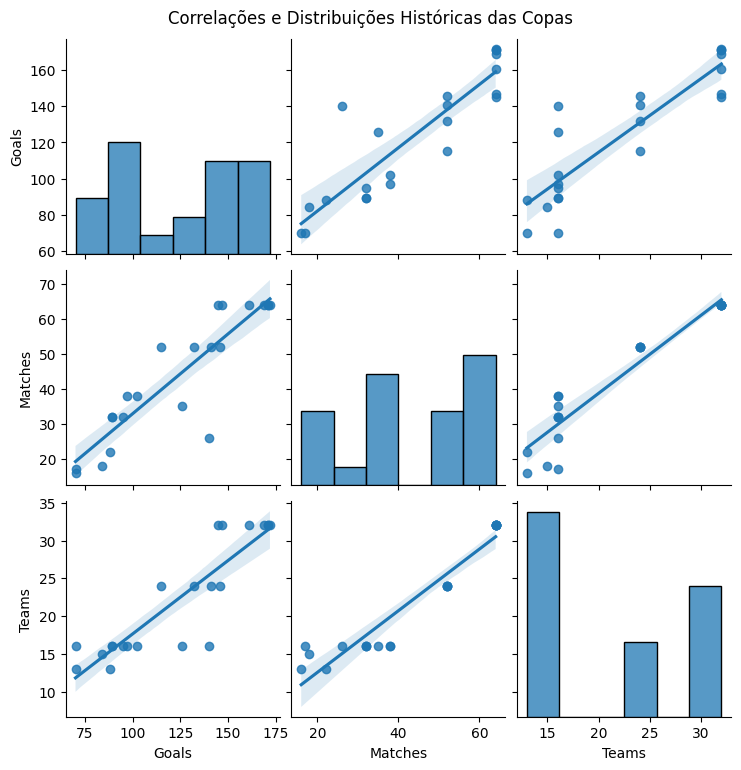

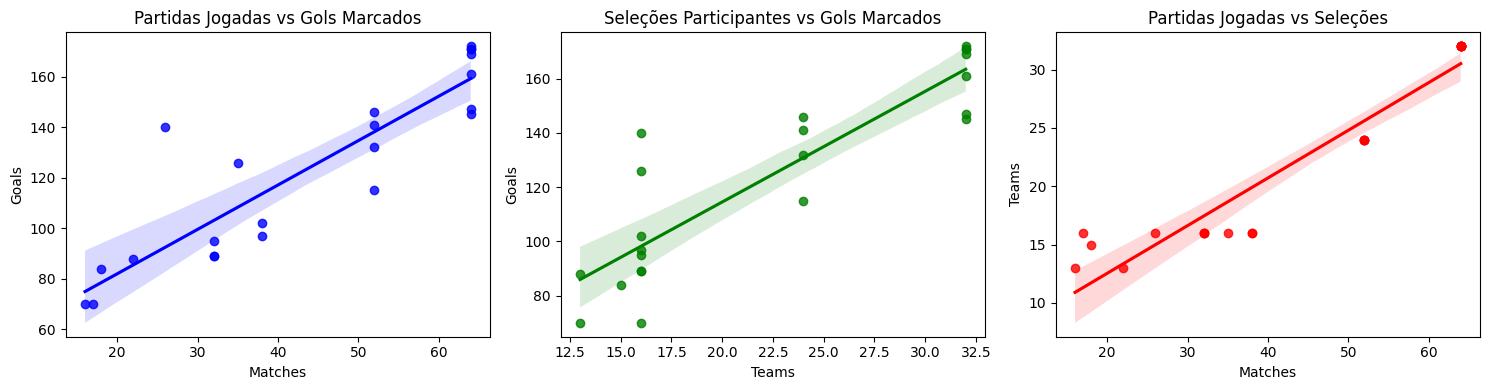

In [ ]:
# ==============================================================================
# 2. ANÁLISE EXPLORATÓRIA DE DADOS (EDA) - Perfil de Performance Histórica
# ==============================================================================
# Pairplot focado na distribuição e correlação das métricas reais do futebol
sns.pairplot(df, vars=features_scouting, kind="reg", palette="viridis", markers=['o'])
plt.suptitle('Correlações e Distribuições Históricas das Copas', y=1.02)
plt.show()

# Gráficos de dispersão com linha de tendência para entender a evolução do esporte
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.regplot(x="Matches", y="Goals", data=df, color='b')
plt.title('Partidas Jogadas vs Gols Marcados')

plt.subplot(1, 3, 2)
sns.regplot(x="Teams", y="Goals", data=df, color='g')
plt.title('Seleções Participantes vs Gols Marcados')

plt.subplot(1, 3, 3)
sns.regplot(x="Matches", y="Teams", data=df, color='r')
plt.title('Partidas Jogadas vs Seleções')

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 3. PRÉ-PROCESSAMENTO (Escalonamento/Normalização) - Crítico para K-Means
# ==============================================================================
scalar = True
scalar_min_max = False

X_raw = df[features_scouting].copy()

if scalar:
    if scalar_min_max:
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_raw)
    # Criamos o DataFrame escalonado para uso nos modelos de distância
    X = pd.DataFrame(X_scaled, columns=X_raw.columns)
    print("\nDados padronizados prontos para os algoritmos (Primeiras 5 linhas):")
    print(X.head())
else:
    X = X_raw.copy()


Dados padronizados prontos para os algoritmos (Primeiras 5 linhas):
      Goals   Matches     Teams
0 -1.575649 -1.596443 -1.242224
1 -1.575649 -1.538866 -0.838348
2 -1.164378 -1.481290 -0.972973
3 -1.046872 -1.250983 -1.242224
4  0.480706 -1.020677 -0.838348



Valores de Inércia por K:
66.0
13.678677366319008
7.6907965198729835
3.9892142853200494
2.080319628311146
1.4394468275319183
1.0456407814493196
0.8268085735480943
0.5607453948848041


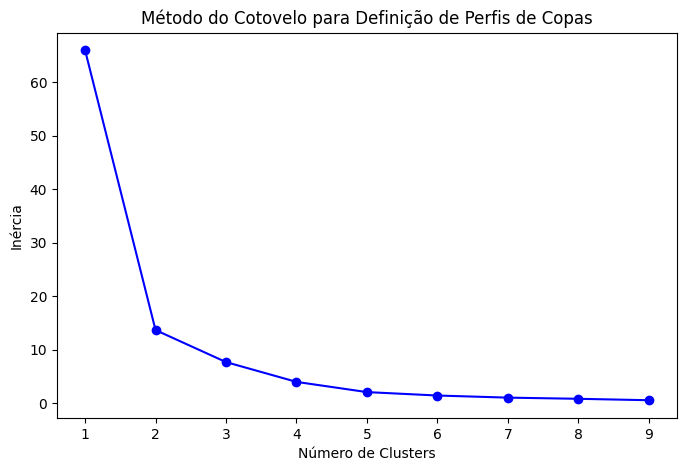

In [ ]:
# ==============================================================================
# 4. MÉTODO DO COTOVELO (Elbow Method) - Definição do K Ideal
# ==============================================================================
inertia = []
k_range = range(1, 10)
for i in k_range:
    means_k = KMeans(n_clusters=i, random_state=0, n_init=10)
    means_k.fit(X)
    inertia.append(means_k.inertia_)

print("\nValores de Inércia por K:")
for i in inertia:
    print(i)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo para Definição de Perfis de Copas')
plt.show()


Visualização do Dataset Rotulado para Redes Neurais:
      Goals   Matches     Teams  Cluster
0 -1.575649 -1.596443 -1.242224        3
1 -1.575649 -1.538866 -0.838348        3
2 -1.164378 -1.481290 -0.972973        3
3 -1.046872 -1.250983 -1.242224        3
4  0.480706 -1.020677 -0.838348        1
Formato final da matriz X: (22, 3)


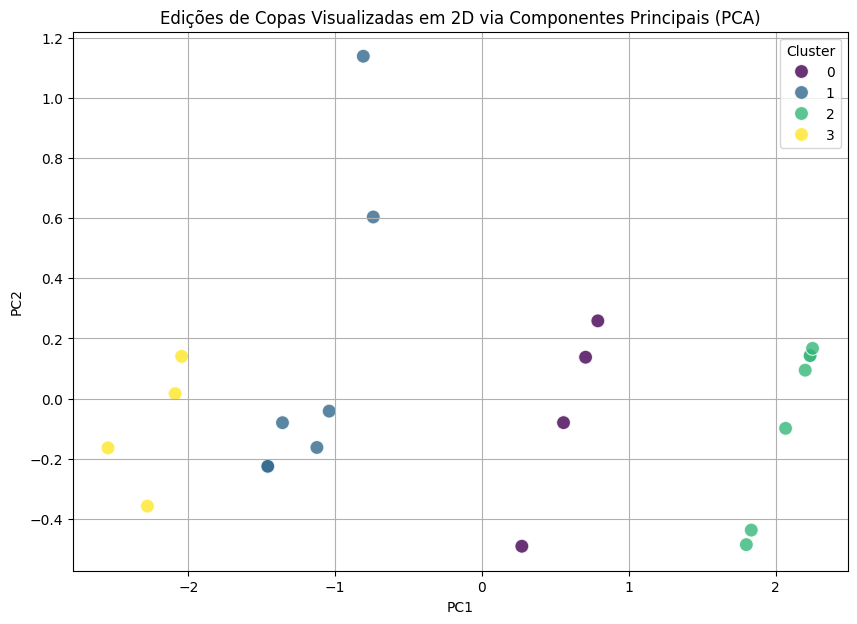

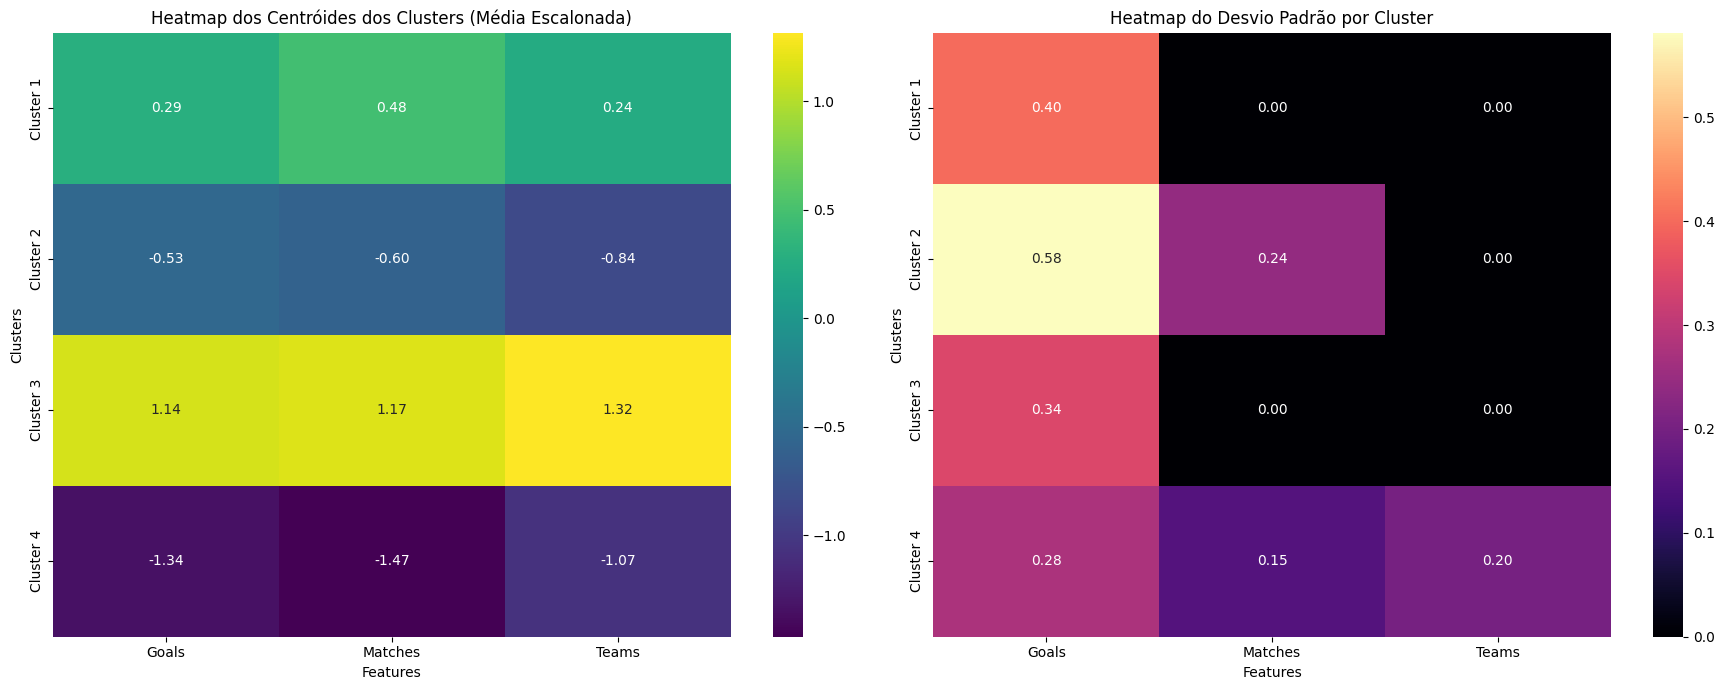

In [ ]:
# ==============================================================================
# 5. TREINAMENTO DO K-MEANS & ANÁLISE DE CENTRÓIDES
# ==============================================================================
# Definindo número ideal baseado no Cotovelo (ex: 4 grupos de eras/estruturas de Copas)
k_escolhido = 4
means_k = KMeans(n_clusters=k_escolhido, random_state=0, n_init=10)
means_k.fit(X)
labels = means_k.labels_
centroids = means_k.cluster_centers_

X_clustered = X.copy()
X_clustered['Cluster'] = labels
X_Para_Rede_Neural = X_clustered.copy()

print("\nVisualização do Dataset Rotulado para Redes Neurais:")
print(X_Para_Rede_Neural.head())
print("Formato final da matriz X:", X.shape)

# Redução de Dimensionalidade (PCA 2D) para Visualização Gráfica dos Clusters reais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
X_pca_df['Cluster'] = labels

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=X_pca_df, palette='viridis', s=100, alpha=0.8)
plt.title('Edições de Copas Visualizadas em 2D via Componentes Principais (PCA)')
plt.grid(True)
plt.show()

# Heatmaps comparativos de Médias (Centróides) e Desvios Padrão
std_devs = X_clustered.groupby('Cluster')[features_scouting].std()

plt.figure(figsize=(18, 7))

# Esquerda: Médias
plt.subplot(1, 2, 1)
sns.heatmap(centroids, annot=True, cmap='viridis', fmt=".2f",
            xticklabels=X.columns, yticklabels=[f'Cluster {i+1}' for i in range(len(centroids))])
plt.title('Heatmap dos Centróides dos Clusters (Média Escalonada)')
plt.xlabel('Features')
plt.ylabel('Clusters')

# Direita: Desvio Padrão
plt.subplot(1, 2, 2)
sns.heatmap(std_devs, annot=True, cmap='magma', fmt=".2f",
            xticklabels=X.columns, yticklabels=[f'Cluster {i+1}' for i in range(len(std_devs))])
plt.title('Heatmap do Desvio Padrão por Cluster')
plt.xlabel('Features')
plt.ylabel('Clusters')

plt.tight_layout()
plt.show()

# Visualização Volumétrica 3D Interativa com Plotly usando as variáveis corretas
trace1 = go.Scatter3d(
    x=X['Goals'],
    y=X['Matches'],
    z=X['Teams'],
    mode='markers',
    marker=dict(
        color=labels,
        size=8,
        opacity=0.9,
        colorscale='Viridis'
    )
)
layout = go.Layout(
    title='Agrupamento Tridimensional de Eras da Copa do Mundo',
    scene=dict(
        xaxis=dict(title='Gols (Escalonado)'),
        yaxis=dict(title='Partidas (Escalonado)'),
        zaxis=dict(title='Seleções (Escalonado)')
    )
)
fig = go.Figure(data=trace1, layout=layout)
py.offline.iplot(fig)


O coeficiente de silhueta médio para k=4 é: 0.6000


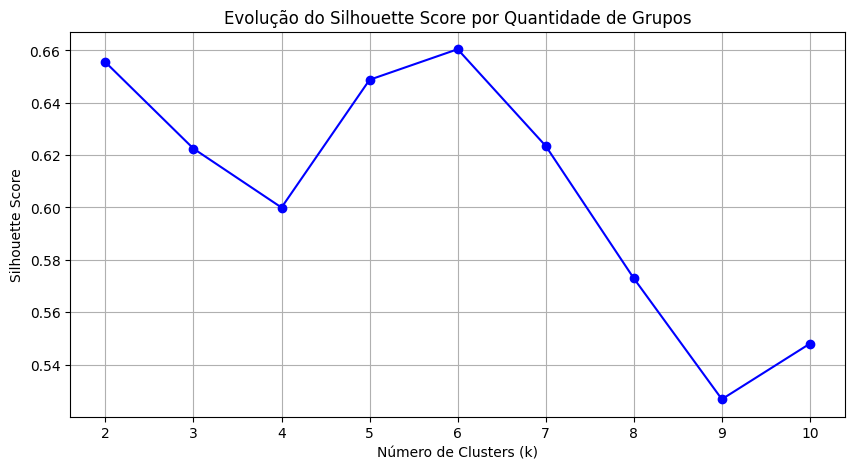


Dataset particionado com sucesso em 4 subgrupos de análise.

--- Estatísticas Descritivas para o Cluster_0 (Amostras: 4) ---


,Goals,Matches,Teams,Cluster
count,4.000000,4.000000,4.000000,4.0
mean,0.289759,0.476316,0.238654,0.0
std,0.400283,0.000000,0.000000,0.0
min,-0.253706,0.476316,0.238654,0.0
25%,0.120844,0.476316,0.238654,0.0
50%,0.377889,0.476316,0.238654,0.0
75%,0.546804,0.476316,0.238654,0.0
max,0.656965,0.476316,0.238654,0.0


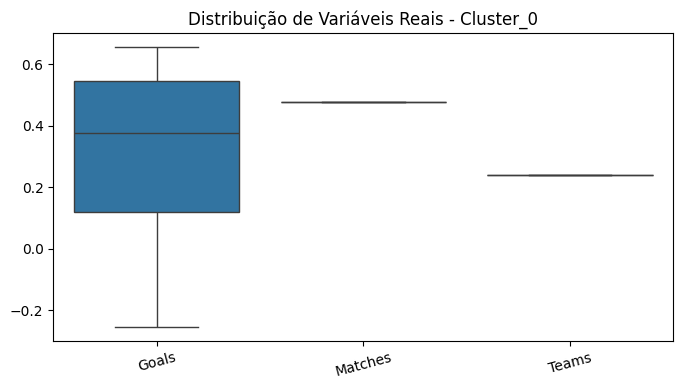


--- Estatísticas Descritivas para o Cluster_1 (Amostras: 7) ---


,Goals,Matches,Teams,Cluster
count,7.000000,7.000000,7.000000,7.0
mean,-0.534881,-0.601190,-0.838348,1.0
std,0.581342,0.241351,0.000000,0.0
min,-1.017495,-1.020677,-0.838348,1.0
25%,-0.929366,-0.675217,-0.838348,1.0
50%,-0.782483,-0.675217,-0.838348,1.0
75%,-0.283083,-0.416122,-0.838348,1.0
max,0.480706,-0.329757,-0.838348,1.0


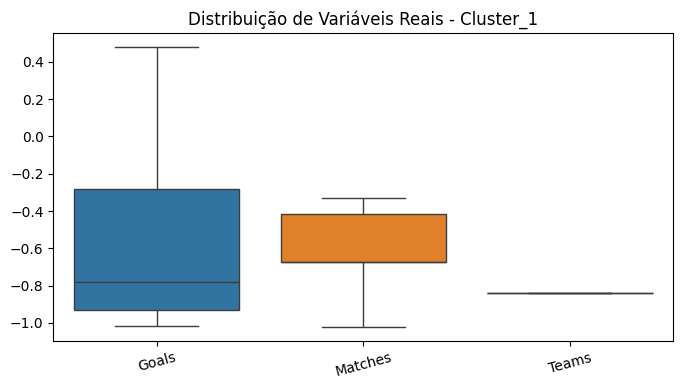


--- Estatísticas Descritivas para o Cluster_2 (Amostras: 7) ---


,Goals,Matches,Teams,Cluster
count,7.000000,7.000000,7.000000,7.0
mean,1.135383,1.167235,1.315655,2.0
std,0.344559,0.000000,0.000000,0.0
min,0.627589,1.167235,1.315655,2.0
25%,0.891977,1.167235,1.315655,2.0
50%,1.332625,1.167235,1.315655,2.0
75%,1.391378,1.167235,1.315655,2.0
max,1.420754,1.167235,1.315655,2.0


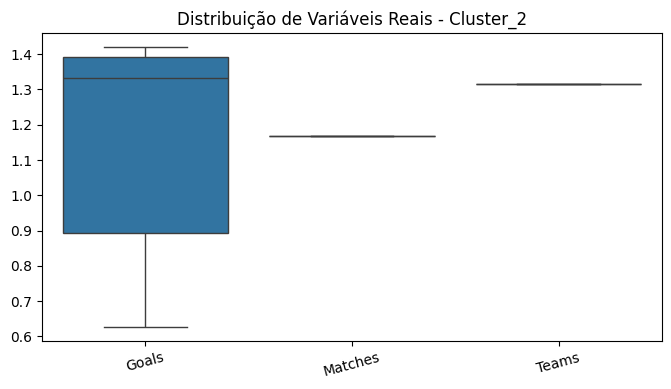


--- Estatísticas Descritivas para o Cluster_3 (Amostras: 4) ---


,Goals,Matches,Teams,Cluster
count,4.000000,4.000000,4.000000,4.0
mean,-1.340637,-1.466896,-1.073942,3.0
std,0.275576,0.151424,0.201938,0.0
min,-1.575649,-1.596443,-1.242224,3.0
25%,-1.575649,-1.553260,-1.242224,3.0
50%,-1.370013,-1.510078,-1.107598,3.0
75%,-1.135001,-1.423713,-0.939317,3.0
max,-1.046872,-1.250983,-0.838348,3.0


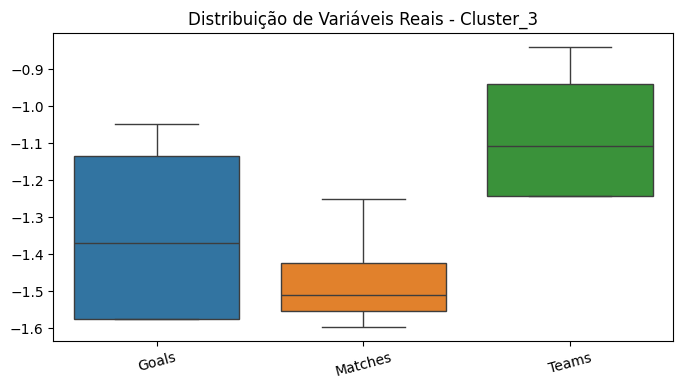

In [ ]:
# ==============================================================================
# 6. VALIDAÇÃO DAS CLUSTERIZAÇÕES (Métricas de Silhueta e Boxplots)
# ==============================================================================
silhouette_avg = silhouette_score(X, labels)
print(f"\nO coeficiente de silhueta médio para k={k_escolhido} é: {silhouette_avg:.4f}")

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans_eval = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans_eval.fit(X)
    score = silhouette_score(X, kmeans_eval.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_values, silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Evolução do Silhouette Score por Quantidade de Grupos')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Particionamento em subconjuntos estruturados e análise Boxplot por grupo
clustered_subsets = {}
num_clusters = len(X_clustered['Cluster'].unique())

for i in range(num_clusters):
    clustered_subsets[f'Cluster_{i}'] = X_clustered[X_clustered['Cluster'] == i]

print(f"\nDataset particionado com sucesso em {num_clusters} subgrupos de análise.")

for cluster_name, subset_df in clustered_subsets.items():
    print(f"\n--- Estatísticas Descritivas para o {cluster_name} (Amostras: {subset_df.shape[0]}) ---")
    display(subset_df.describe())

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=subset_df.drop(columns=['Cluster']))
    plt.title(f"Distribuição de Variáveis Reais - {cluster_name}")
    plt.xticks(rotation=15)
    plt.show()


Coeficiente de Correlação Cofenética (Método Ward): 0.8496
Coeficiente de Correlação Cofenética (Método Average): 0.8585


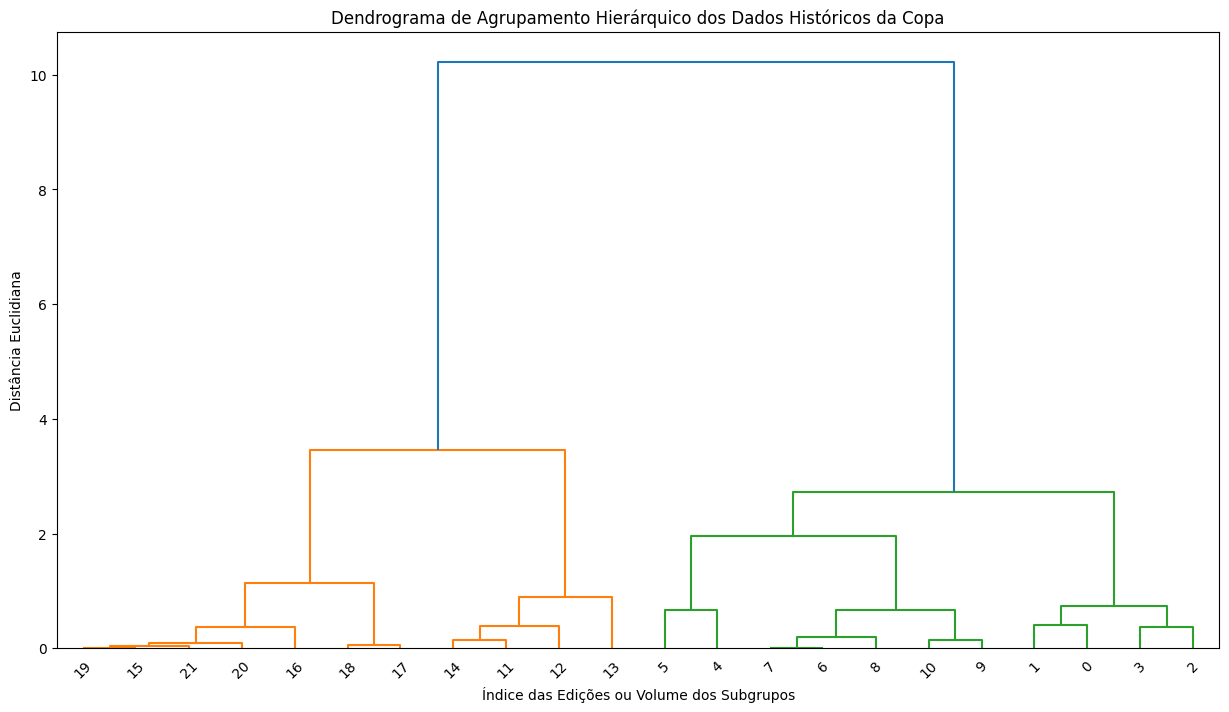


--- Avaliação de Janela de Silhueta Hierárquica ---
Número de Agrupamentos Hierárquicos: 2 | Silhouette Score: 0.6555
Número de Agrupamentos Hierárquicos: 3 | Silhouette Score: 0.6225
Número de Agrupamentos Hierárquicos: 4 | Silhouette Score: 0.6000
Número de Agrupamentos Hierárquicos: 5 | Silhouette Score: 0.6488
Número de Agrupamentos Hierárquicos: 6 | Silhouette Score: 0.6605
Número de Agrupamentos Hierárquicos: 7 | Silhouette Score: 0.6235
Número de Agrupamentos Hierárquicos: 8 | Silhouette Score: 0.5761
Número de Agrupamentos Hierárquicos: 9 | Silhouette Score: 0.5268
Número de Agrupamentos Hierárquicos: 10 | Silhouette Score: 0.5480

[Sugestão Algorítmica]: O número ideal encontrado pelo Hierárquico é 6 clusters (Score: 0.6605)


In [ ]:
# ==============================================================================
# 7. AGRUPAMENTO HIERÁRQUICO (Dendrograma Coeficiente Cofenético)
# ==============================================================================
# Computa matriz de ligação pelo critério de Ward
linked = linkage(X, method='ward')

dist_original = pdist(X)
c, coph_dists = cophenet(linked, dist_original)
print(f"\nCoeficiente de Correlação Cofenética (Método Ward): {c:.4f}")

# Avaliação comparativa de algoritmos de Linkage
Z_avg = linkage(X, method='average')
c_avg, _ = cophenet(Z_avg, dist_original)
print(f"Coeficiente de Correlação Cofenética (Método Average): {c_avg:.4f}")

# Renderização do Dendrograma de Agrupamento
plt.figure(figsize=(15, 8))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrograma de Agrupamento Hierárquico dos Dados Históricos da Copa')
plt.xlabel('Índice das Edições ou Volume dos Subgrupos')
plt.ylabel('Distância Euclidiana')
plt.show()

# Realiza o corte do Dendrograma
clusters_hierarquico = fcluster(linked, t=k_escolhido, criterion='maxclust')
df['cluster_final'] = clusters_hierarquico

# Otimização automatizada do ponto de corte na árvore hierárquica via Silhueta
resultados_silhueta_h = []
print("\n--- Avaliação de Janela de Silhueta Hierárquica ---")

for k in range(2, 11):
    labels_h = fcluster(linked, t=k, criterion='maxclust')
    score_h = silhouette_score(X, labels_h)
    resultados_silhueta_h.append((k, score_h))
    print(f"Número de Agrupamentos Hierárquicos: {k} | Silhouette Score: {score_h:.4f}")

melhor_k, melhor_score = max(resultados_silhueta_h, key=lambda item: item[1])
print(f"\n[Sugestão Algorítmica]: O número ideal encontrado pelo Hierárquico é {melhor_k} clusters (Score: {melhor_score:.4f})")

In [ ]:
# Unindo os dados textuais originais com os clusters que o algoritmo descobriu
df_analise = df.copy()
df_analise['Cluster'] = labels

# Vamos ver quem foram os campeões de cada "Era" (Cluster) definida pelo K-Means
for i in range(k_escolhido):
    print(f"\n================ COMANDANTES DA ERA - CLUSTER {i+1} ================")
    copas_do_grupo = df_analise[df_analise['Cluster'] == i]

    # Lista os anos, sedes e campeões das Copas que caíram nesse grupo
    for idx, row in copas_do_grupo.iterrows():
        print(f"Ano: {row['YEAR']} | Sede: {row['HOST']} | Campeão: {row['CHAMPION']} (Gols Totais na Copa: {row['Goals']})")


================ COMANDANTES DA ERA - CLUSTER 1 ================
Ano: 1982 | Sede: Spain | Campeão: Italy (Gols Totais na Copa: 146)
Ano: 1986 | Sede: Mexico | Campeão: Argentina (Gols Totais na Copa: 132)
Ano: 1990 | Sede: Italy | Campeão: West Germany (Gols Totais na Copa: 115)
Ano: 1994 | Sede: United States | Campeão: Brazil (Gols Totais na Copa: 141)

================ COMANDANTES DA ERA - CLUSTER 2 ================
Ano: 1954 | Sede: Switzerland | Campeão: West Germany (Gols Totais na Copa: 140)
Ano: 1958 | Sede: Sweden | Campeão: Brazil (Gols Totais na Copa: 126)
Ano: 1962 | Sede: Chile | Campeão: Brazil (Gols Totais na Copa: 89)
Ano: 1966 | Sede: England | Campeão: England (Gols Totais na Copa: 89)
Ano: 1970 | Sede: Mexico | Campeão: Brazil (Gols Totais na Copa: 95)
Ano: 1974 | Sede: West Germany | Campeão: West Germany (Gols Totais na Copa: 97)
Ano: 1978 | Sede: Argentina | Campeão: Argentina (Gols Totais na Copa: 102)

================ COMANDANTES DA ERA - CLUSTER 3 ==========